In [1]:
import yfinance as yf
import pandas as pd
from pathlib import Path

In [2]:
# Nifty 50 index ticker on Yahoo Finance
TICKER = "^NSEI"

df = yf.download(TICKER, start="2015-01-01", end="2026-01-01", auto_adjust=True)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900
2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200
2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800
2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100
2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800


In [6]:
# Flatten MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,8395.450195,8410.599609,8288.700195,8288.700195,101900
2015-01-05,8378.400391,8445.599609,8363.900391,8407.950195,118200
2015-01-06,8127.350098,8327.849609,8111.350098,8325.299805,172800
2015-01-07,8102.100098,8151.200195,8065.450195,8118.649902,164100
2015-01-08,8234.599609,8243.500000,8167.299805,8191.399902,143800


In [7]:
print(df.shape)
print(df.index.min(), "to", df.index.max())
df.isna().sum()

(2708, 5)
2015-01-02 00:00:00 to 2025-12-31 00:00:00


Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [8]:
raw_path = Path("../data/raw/nifty50_raw.csv")
raw_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(raw_path)
print(f"Saved to {raw_path.resolve()}")

Saved to C:\Users\Parth Sharma\nifty50-direction-prediction\data\raw\nifty50_raw.csv


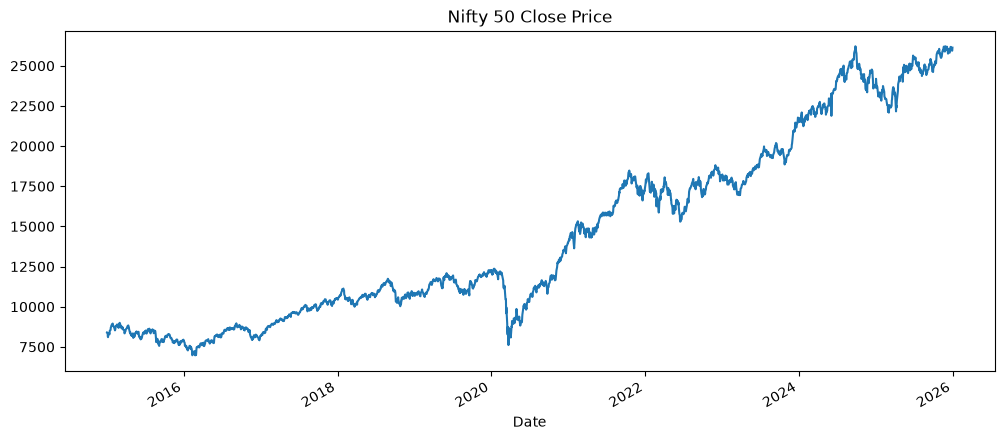

In [9]:
import matplotlib.pyplot as plt

df["Close"].plot(figsize=(12,5), title="Nifty 50 Close Price")
plt.show()